# Zara Women's Collection - Data Exploration

Comprehensive analysis of Zara's women's fashion dataset including pricing, categories, colors, and product features.

## 1. Data Import and Setup

In [ ]:
! pip install matplotlib
! pip install seaborn
! pip install plotly
! pip install nbformat
! pip install ipython


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [20]:
! pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.9/168.9 kB 1.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
from collections import Counter
import nbformat
import IPython.display as display
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
# Load the dataset
df = pd.read_csv('women_all_categories_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1691, 8)


,product_url,product_name,mrp,color,reference_number,description,product_image,product_category
0,https://www.zara.com/es/en/limited-edition-zw-...,ZW COLLECTION LIMITED EDITION WOOL BLAZER WITH...,89.95 EUR,MID-GREY,2159/727/809,ZARA WOMAN COLLECTION Jacket made of 100% woo...,https://static.zara.net/assets/public/7dba/b75...,JACKETS
1,https://www.zara.com/es/en/asymmetric-check-bl...,ASYMMETRIC CHECK BLAZER WITH WOOL ZW COLLECTIO...,109.00 EUR,STONE,2086/827/806,ZARA WOMAN COLLECTION Blazer with main fabric...,https://static.zara.net/assets/public/7b0a/c07...,JACKETS
2,https://www.zara.com/es/en/leather-effect-wais...,LEATHER EFFECT WAISTCOAT WITH TABS,35.95 EUR,BLUE,1255/817/407,Gilet with a high collar and armholes with tab...,https://static.zara.net/assets/public/f69e/4e4...,JACKETS
3,https://www.zara.com/es/en/faux-leather-jacket...,LEATHER EFFECT JACKET WITH STRAPS,49.95 EUR,BROWN,8490/701/700,"Jacket with a high neck, long sleeves with ple...",https://static.zara.net/assets/public/e479/750...,JACKETS
4,https://www.zara.com/es/en/asymmetric-check-bl...,ASYMMETRIC CHECK BLAZER WITH WOOL ZW COLLECTIO...,109.00 EUR,STONE,2086/827/806,ZARA WOMAN COLLECTION Blazer with main fabric...,https://static.zara.net/assets/public/7b0a/c07...,JACKETS


## 2. Dataset Overview & Quality Assessment

In [5]:
# Basic dataset information
print('=== DATASET OVERVIEW ===')
print(f'Shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('Column info:')
df.info()
print('Data types:')
print(df.dtypes)

=== DATASET OVERVIEW ===
Shape: (1691, 8)
Memory usage: 1.33 MB
Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1691 entries, 0 to 1690
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   product_url       1691 non-null   object
 1   product_name      1691 non-null   object
 2   mrp               1691 non-null   object
 3   color             1691 non-null   object
 4   reference_number  1691 non-null   object
 5   description       1691 non-null   object
 6   product_image     1691 non-null   object
 7   product_category  1691 non-null   object
dtypes: object(8)
memory usage: 105.8+ KB
Data types:
product_url         object
product_name        object
mrp                 object
color               object
reference_number    object
description         object
product_image       object
product_category    object
dtype: object


In [8]:
# "Not available" values count from product_image column 
notavailable = df['product_image'].value_counts().get('Not available', 0)
print(f'Number of "Not available" entries in product_image column: {notavailable}')


Number of "Not available" entries in product_image column: 45


In [9]:
# Duplicate analysis
print('=== DUPLICATE ANALYSIS ===')
print(f'Total duplicates: {df.duplicated().sum()}')
print(f'Duplicate URLs: {df.duplicated(subset=["product_url"]).sum()}')
print(f'Duplicate products (name + color): {df.duplicated(subset=["product_name", "color"]).sum()}')

# Show duplicate examples
if df.duplicated().sum() > 0:
    print('Duplicate examples:')
    print(df[df.duplicated(keep=False)].head())
    
# After analyzing the website, this is because the same product is show several times with different images in the product page. 

=== DUPLICATE ANALYSIS ===
Total duplicates: 911
Duplicate URLs: 954
Duplicate products (name + color): 965
Duplicate examples:
                                          product_url  \
1   https://www.zara.com/es/en/asymmetric-check-bl...   
4   https://www.zara.com/es/en/asymmetric-check-bl...   
7   https://www.zara.com/es/en/faux-leather-jacket...   
10  https://www.zara.com/es/en/high-neck-bomber-ja...   
11  https://www.zara.com/es/en/high-neck-bomber-ja...   

                                         product_name         mrp  \
1   ASYMMETRIC CHECK BLAZER WITH WOOL ZW COLLECTIO...  109.00 EUR   
4   ASYMMETRIC CHECK BLAZER WITH WOOL ZW COLLECTIO...  109.00 EUR   
7                                 FAUX LEATHER JACKET   59.95 EUR   
10                            HIGH-NECK BOMBER JACKET   45.95 EUR   
11                            HIGH-NECK BOMBER JACKET   45.95 EUR   

           color reference_number  \
1          STONE     2086/827/806   
4          STONE     2086/827/806   
7  

## 3. Price Analysis

In [10]:
# Clean and extract price data
def extract_price(price_str):
    if pd.isna(price_str) or price_str == 'Not available':
        return np.nan
    # Extract numeric value from price string
    price_match = re.search(r'([0-9]+\.?[0-9]*)', str(price_str))
    if price_match:
        return float(price_match.group(1))
    return np.nan

df['price_numeric'] = df['mrp'].apply(extract_price)

print('=== PRICE STATISTICS ===')
print(df['price_numeric'].describe())
print(f'Price range: €{df["price_numeric"].min():.2f} - €{df["price_numeric"].max():.2f}')

=== PRICE STATISTICS ===
count    1691.000000
mean       47.594175
std        56.326110
min         5.950000
25%        25.950000
50%        29.950000
75%        49.950000
max       699.000000
Name: price_numeric, dtype: float64
Price range: €5.95 - €699.00


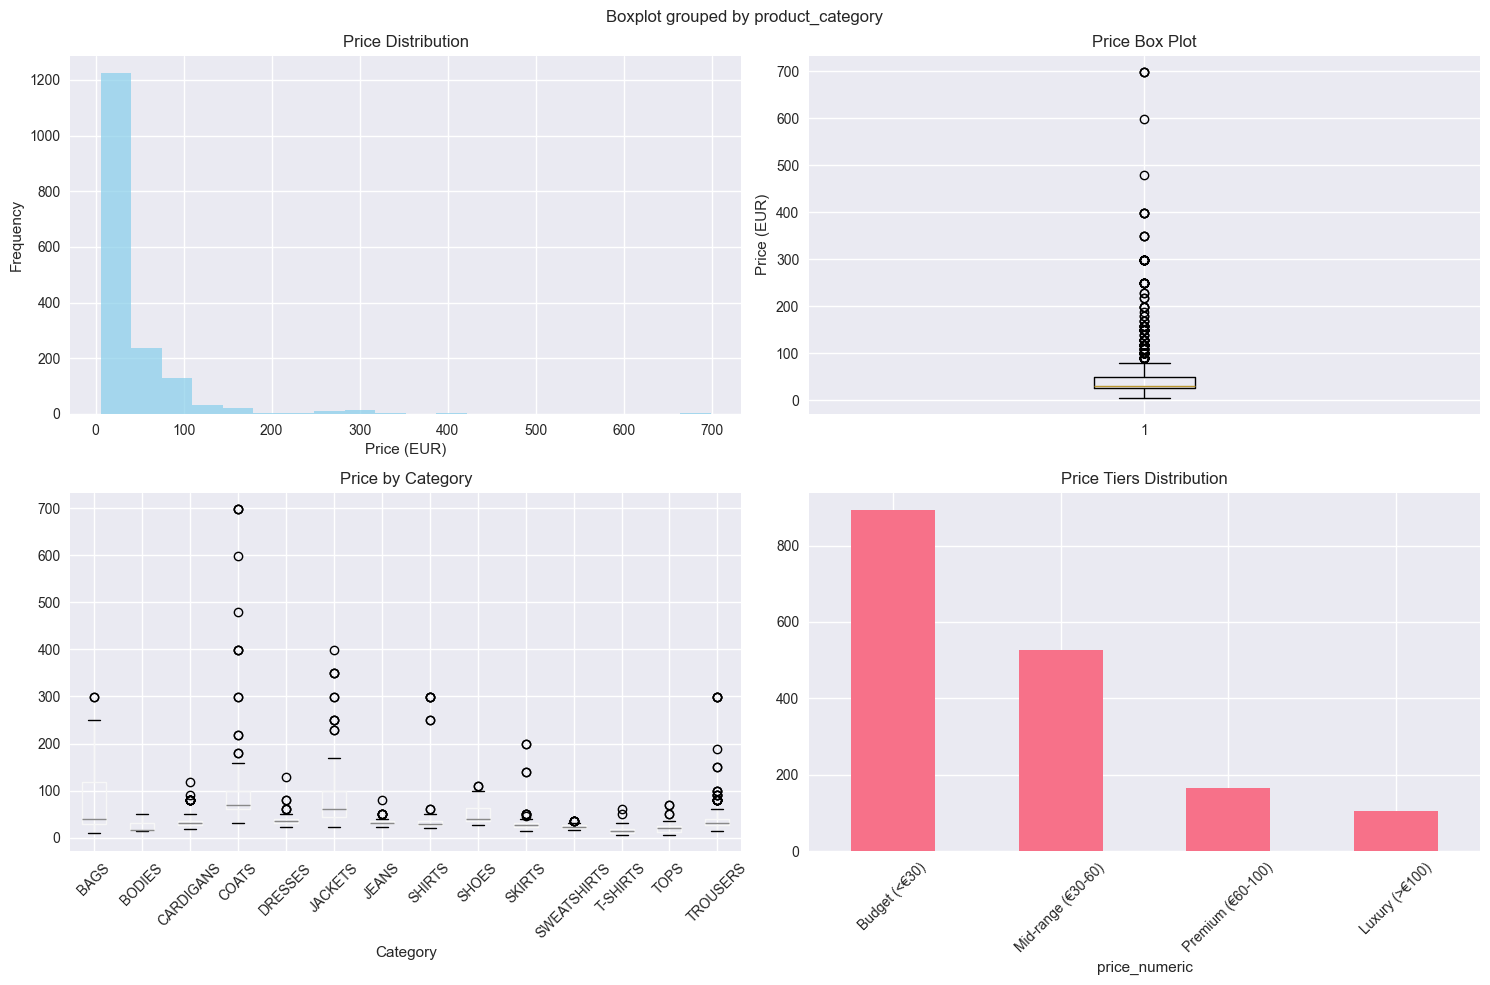

In [11]:
# Price distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0,0].hist(df['price_numeric'].dropna(), bins=20, alpha=0.7, color='skyblue')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (EUR)')
axes[0,0].set_ylabel('Frequency')

# Box plot
axes[0,1].boxplot(df['price_numeric'].dropna())
axes[0,1].set_title('Price Box Plot')
axes[0,1].set_ylabel('Price (EUR)')

# Price by category
df.boxplot(column='price_numeric', by='product_category', ax=axes[1,0])
axes[1,0].set_title('Price by Category')
axes[1,0].set_xlabel('Category')
axes[1,0].tick_params(axis='x', rotation=45)

# Price tiers
price_tiers = pd.cut(df['price_numeric'], bins=[0, 30, 60, 100, float('inf')], 
                    labels=['Budget (<€30)', 'Mid-range (€30-60)', 'Premium (€60-100)', 'Luxury (>€100)'])
price_tiers.value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Price Tiers Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Product Category Analysis

=== CATEGORY ANALYSIS ===
Category distribution:
product_category
CARDIGANS      240
SHOES          228
TROUSERS       198
JEANS          158
T-SHIRTS       147
JACKETS        136
BAGS           129
COATS          104
SKIRTS          94
TOPS            72
SHIRTS          67
SWEATSHIRTS     53
DRESSES         43
BODIES          22
Name: count, dtype: int64


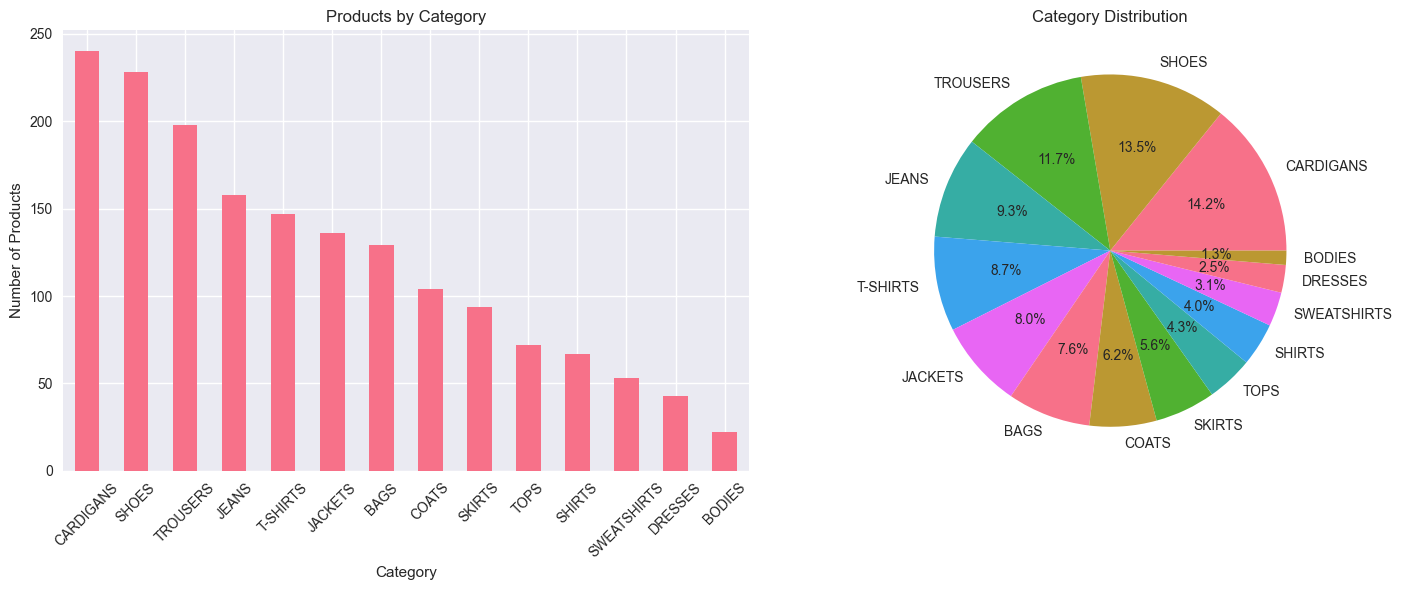

In [12]:
# Category distribution
print('=== CATEGORY ANALYSIS ===')
category_counts = df['product_category'].value_counts()
print('Category distribution:')
print(category_counts)

# Visualize category distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
category_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Products by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Products')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
category_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Category Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [13]:
pip install ipython


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
# Category price analysis
category_price_stats = df.groupby('product_category')['price_numeric'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
print('Price statistics by category:')
print(category_price_stats)

# Interactive plot with Plotly
fig = px.box(df, x='product_category', y='price_numeric', 
    title='Price Distribution by Category',
    labels={'price_numeric': 'Price (EUR)', 'product_category': 'Category'})
fig.update_xaxes(tickangle=45)
fig.show()

Price statistics by category:
                  count    mean  median     std    min     max
product_category                                              
BAGS                129   73.44   39.95   65.28   9.95  299.00
BODIES               22   22.54   15.95   10.43  12.95   49.95
CARDIGANS           240   33.27   29.95   13.49  17.95  119.00
COATS               104  118.94   69.95  138.77  29.95  699.00
DRESSES              43   41.28   35.95   18.52  22.95  129.00
JACKETS             136   83.80   59.95   71.15  22.95  399.00
JEANS               158   33.61   29.95    6.69  22.95   79.95
SHIRTS               67   52.91   27.95   73.31  19.95  299.00
SHOES               228   50.07   39.95   20.58  25.95  109.00
SKIRTS               94   34.14   25.95   30.15  12.95  199.00
SWEATSHIRTS          53   24.04   22.95    5.71  15.95   35.95
T-SHIRTS            147   14.83   12.95    7.08   5.95   59.95
TOPS                 72   21.41   19.95   12.41   5.95   69.95
TROUSERS            198  

## 5. Color Analysis

=== COLOR ANALYSIS ===
Top 15 colors:
color
BROWN           267
BLACK           261
BLUE             90
ECRU             68
CHOCOLATE        65
NAVY BLUE        59
WHITE            54
DARK BROWN       41
BURGUNDY RED     39
GREY             33
MINK             32
SAND / MARL      31
BEIGE            29
BURGUNDY         27
GREEN            27
Name: count, dtype: int64


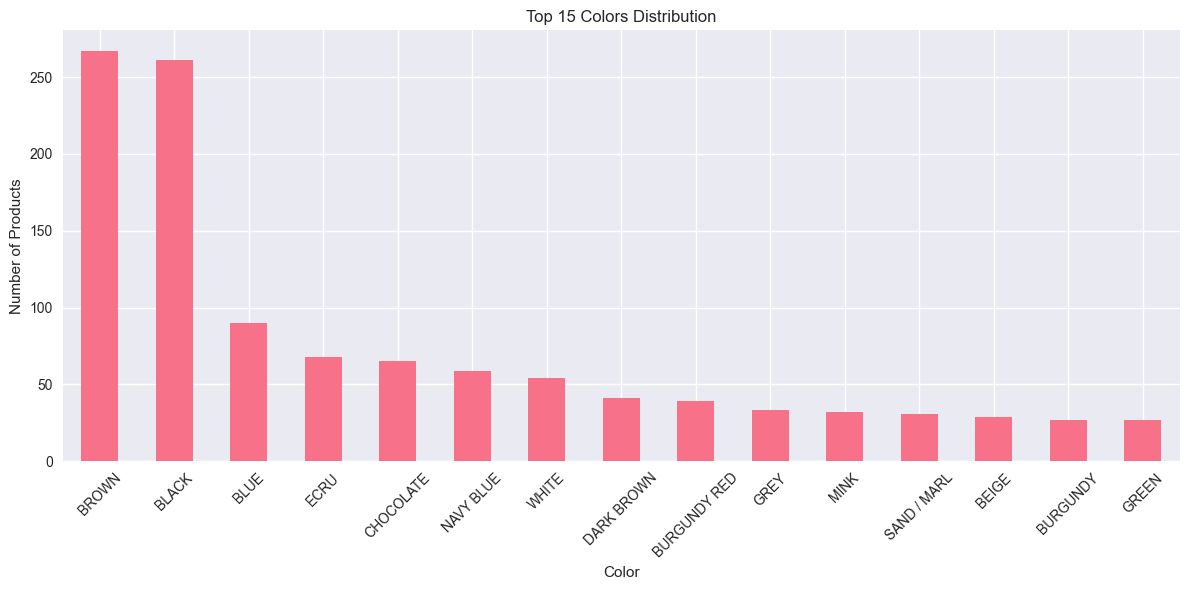

Total unique colors: 112


In [16]:
# Color analysis
print('=== COLOR ANALYSIS ===')
color_counts = df['color'].value_counts().head(15)
print('Top 15 colors:')
print(color_counts)

# Visualize top colors
plt.figure(figsize=(12, 6))
color_counts.plot(kind='bar')
plt.title('Top 15 Colors Distribution')
plt.xlabel('Color')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Total unique colors: {df["color"].nunique()}')

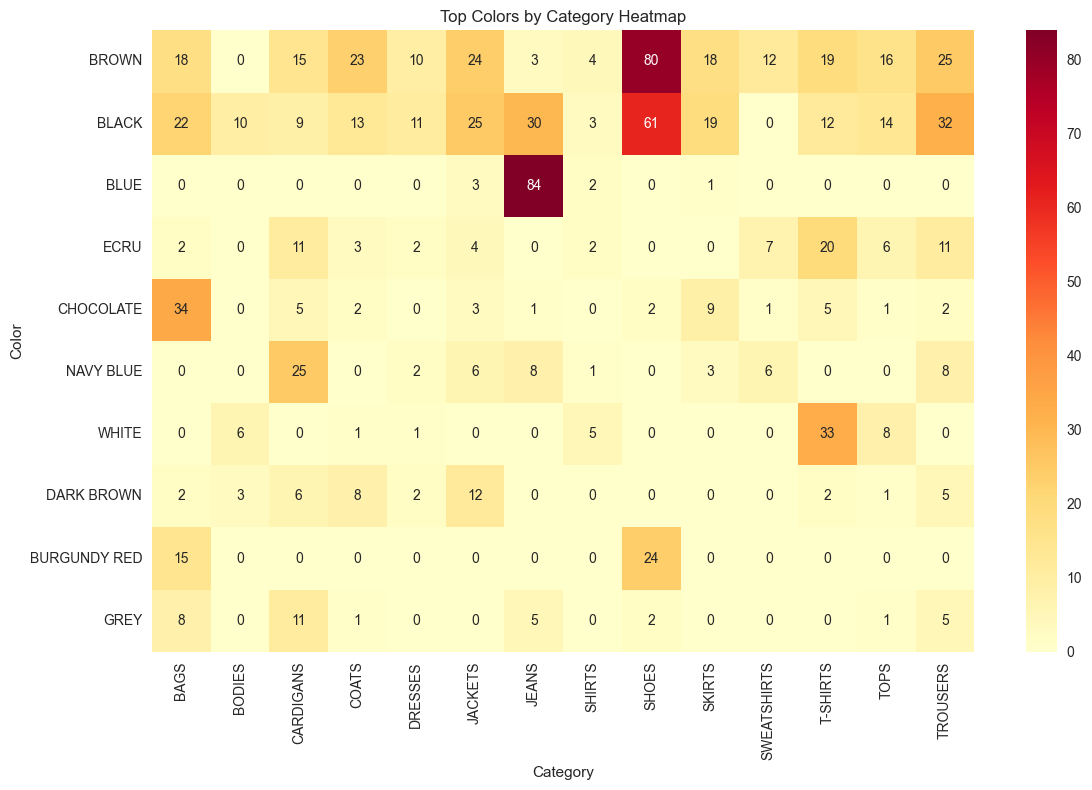

In [17]:
# Color by category heatmap
color_category = pd.crosstab(df['color'], df['product_category'])

# Show only top colors for readability
top_colors = df['color'].value_counts().head(10).index
color_category_top = color_category.loc[top_colors]

plt.figure(figsize=(12, 8))
sns.heatmap(color_category_top, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Top Colors by Category Heatmap')
plt.xlabel('Category')
plt.ylabel('Color')
plt.tight_layout()
plt.show()

## 6. Product Name & Description Analysis

In [19]:
# Text analysis of product names and descriptions
def extract_keywords(text_series, top_n=20):
    # Combine all text and extract words
    all_text = ' '.join(text_series.dropna().astype(str).str.lower())
    # Remove common words and extract meaningful terms
    words = re.findall(r'\b[a-z]{3,}\b', all_text)
    # Filter out common words
    stop_words = {'the', 'and', 'with', 'for', 'are', 'this', 'that', 'from', 'not', 'available'}
    words = [w for w in words if w not in stop_words]
    return Counter(words).most_common(top_n)

print('=== TEXT ANALYSIS ===')

# Product name keywords
name_keywords = extract_keywords(df['product_name'])
print('Top keywords in product names:')
for word, count in name_keywords:
    print(f'{word}: {count}')

# Description keywords
desc_keywords = extract_keywords(df['description'])
print('Top keywords in descriptions:')
for word, count in desc_keywords[:10]:
    print(f'{word}: {count}')

=== TEXT ANALYSIS ===
Top keywords in product names:
collection: 233
leather: 211
trousers: 210
knit: 195
high: 183
shirt: 170
jumper: 166
waist: 164
jeans: 153
wide: 143
jacket: 131
leg: 128
bag: 125
soft: 116
wool: 115
suede: 110
boots: 110
top: 101
coat: 99
faux: 91
Top keywords in descriptions:
front: 1124
fastening: 795
long: 758
high: 672
zip: 667
pockets: 634
neck: 619
waist: 595
button: 574
featuring: 526


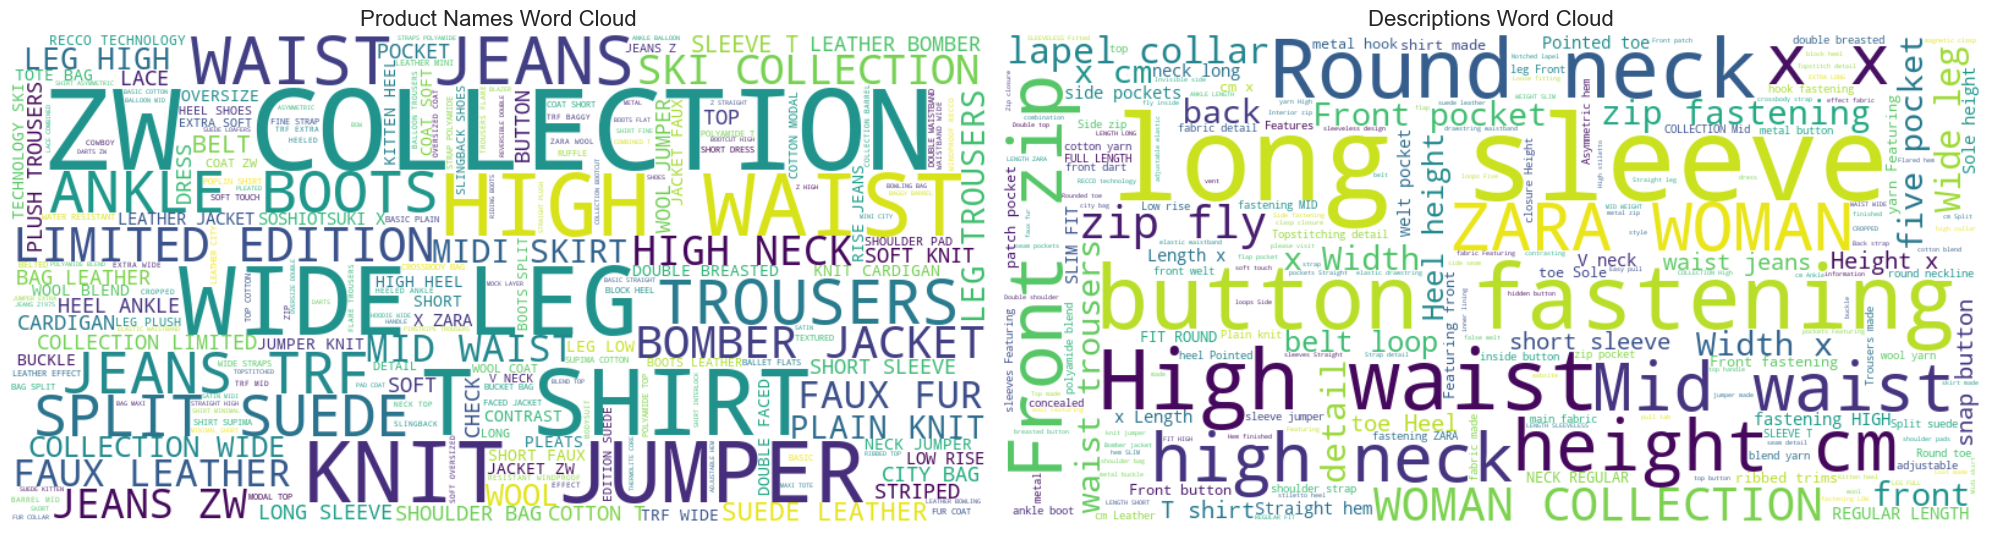

In [ ]:
# # Word clouds
# fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# # Product names word cloud
# name_text = ' '.join(df['product_name'].dropna().astype(str))
# wordcloud_names = WordCloud(width=800, height=400, background_color='white').generate(name_text)
# axes[0].imshow(wordcloud_names, interpolation='bilinear')
# axes[0].set_title('Product Names Word Cloud', fontsize=16)
# axes[0].axis('off')

# # Descriptions word cloud
# desc_text = ' '.join(df['description'].dropna().astype(str))
# wordcloud_desc = WordCloud(width=800, height=400, background_color='white').generate(desc_text)
# axes[1].imshow(wordcloud_desc, interpolation='bilinear')
# axes[1].set_title('Descriptions Word Cloud', fontsize=16)
# axes[1].axis('off')

plt.tight_layout()
plt.show()

## 7. Style & Feature Analysis

In [22]:
# Extract style features from product names and descriptions
def extract_style_features(df):
    # Combine name and description for analysis
    df['full_text'] = (df['product_name'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
    
    # Define style categories
    style_features = {
        'length': ['mini', 'midi', 'maxi', 'short', 'long', 'cropped'],
        'fit': ['oversized', 'fitted', 'loose', 'tight', 'slim', 'wide'],
        'sleeve': ['sleeveless', 'short sleeve', 'long sleeve', 'puff sleeve'],
        'neckline': ['v-neck', 'high neck', 'boat neck', 'round neck', 'collar'],
        'material': ['cotton', 'silk', 'wool', 'leather', 'denim', 'satin', 'lace', 'velvet'],
        'style': ['casual', 'formal', 'vintage', 'modern', 'classic', 'trendy']
    }
    
    # Extract features
    for category, features in style_features.items():
        for feature in features:
            df[f'{category}_{feature}'] = df['full_text'].str.contains(feature, na=False)
    
    return df

df_features = extract_style_features(df.copy())

# Analyze style features
print('=== STYLE FEATURES ANALYSIS ===')

# Length analysis
length_cols = [col for col in df_features.columns if col.startswith('length_')]
length_counts = df_features[length_cols].sum().sort_values(ascending=False)
print('Length features:')
print(length_counts)

# Material analysis
material_cols = [col for col in df_features.columns if col.startswith('material_')]
material_counts = df_features[material_cols].sum().sort_values(ascending=False)
print('Material features:')
print(material_counts)

=== STYLE FEATURES ANALYSIS ===
Length features:
length_long       715
length_short      167
length_midi        62
length_mini        54
length_cropped     27
length_maxi        23
dtype: int64
Material features:
material_leather    221
material_cotton     149
material_wool       135
material_lace        90
material_satin       35
material_velvet       8
material_denim        7
material_silk         1
dtype: int64


## 8. Image Data Analysis

=== IMAGE DATA ANALYSIS ===
Total products: 1691
Products with images: 1646
Products without images: 45
Image availability %: 97.33885274985215
Image availability by category:
                  images_available  total_products  image_percentage
product_category                                                    
BAGS                           129             129            100.00
BODIES                          22              22            100.00
CARDIGANS                      236             240             98.33
COATS                          101             104             97.12
DRESSES                         43              43            100.00
JACKETS                        103             136             75.74
JEANS                          158             158            100.00
SHIRTS                          67              67            100.00
SHOES                          228             228            100.00
SKIRTS                          93              94             98

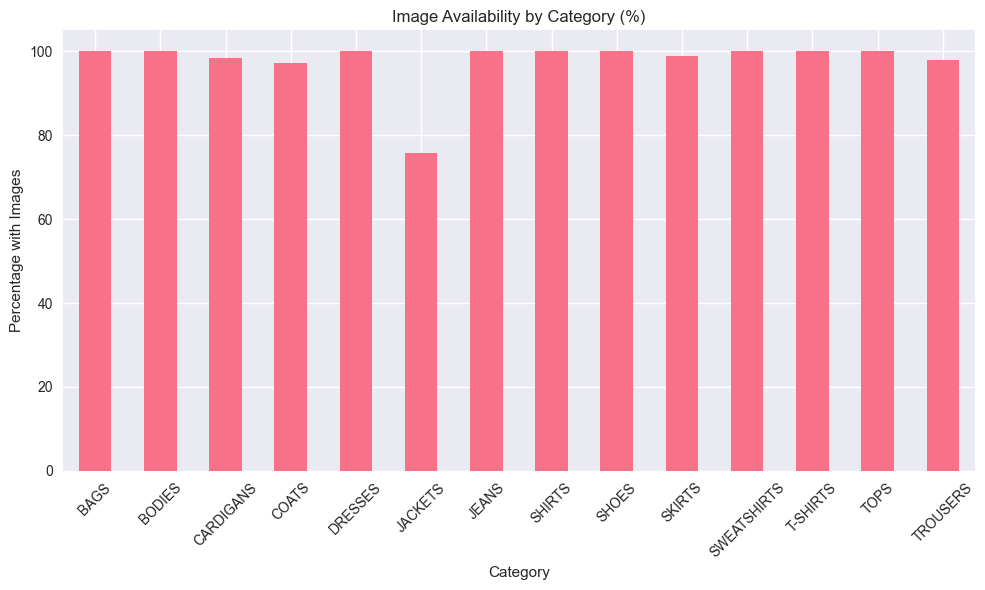

In [25]:
# Image availability analysis
print('=== IMAGE DATA ANALYSIS ===')

# Check image availability
has_image = ~df['product_image'].isin(['Not available', np.nan])
image_stats = {
    'Total products': len(df),
    'Products with images': has_image.sum(),
    'Products without images': (~has_image).sum(),
    'Image availability %': (has_image.sum() / len(df)) * 100
}

for key, value in image_stats.items():
    print(f'{key}: {value}')

# Image availability by category
image_by_category = df.groupby('product_category').agg({
    'product_image': lambda x: (~x.isin(['Not available', np.nan])).sum()
}).rename(columns={'product_image': 'images_available'})

category_totals = df['product_category'].value_counts()
image_by_category['total_products'] = category_totals
image_by_category['image_percentage'] = (image_by_category['images_available'] / image_by_category['total_products']) * 100

print('Image availability by category:')
print(image_by_category.round(2))

# Visualize
plt.figure(figsize=(10, 6))
image_by_category['image_percentage'].plot(kind='bar')
plt.title('Image Availability by Category (%)')
plt.xlabel('Category')
plt.ylabel('Percentage with Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Correlation & Relationship Analysis

In [ ]:
# Correlation analysis
print('=== CORRELATION ANALYSIS ===')

# Create numerical features for correlation
df_corr = df.copy()

# Encode categorical variables
df_corr['category_encoded'] = pd.Categorical(df_corr['product_category']).codes
df_corr['has_image'] = ~df_corr['product_image'].isin(['Not available', np.nan])
df_corr['name_length'] = df_corr['product_name'].str.len()
df_corr['desc_length'] = df_corr['description'].str.len()

# Select numerical columns for correlation
corr_cols = ['price_numeric', 'category_encoded', 'has_image', 'name_length', 'desc_length']
correlation_matrix = df_corr[corr_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlation with price:')
price_corr = correlation_matrix['price_numeric'].sort_values(ascending=False)
print(price_corr)

## 10. Summary & Key Insights

In [26]:
# Generate summary insights
print('=== KEY INSIGHTS SUMMARY ===')
print()

# Dataset overview
print(f'📊 Dataset Overview:')
print(f'   • Total products: {len(df):,}')
print(f'   • Categories: {df["product_category"].nunique()}')
print(f'   • Unique colors: {df["color"].nunique()}')
print(f'   • Price range: €{df["price_numeric"].min():.2f} - €{df["price_numeric"].max():.2f}')
print()

# Category insights
top_category = df['product_category'].value_counts().index[0]
top_category_count = df['product_category'].value_counts().iloc[0]
print(f'🏷️  Category Insights:')
print(f'   • Largest category: {top_category} ({top_category_count} products)')
print(f'   • Most expensive category: {category_price_stats["mean"].idxmax()} (avg €{category_price_stats["mean"].max():.2f})')
print(f'   • Most affordable category: {category_price_stats["mean"].idxmin()} (avg €{category_price_stats["mean"].min():.2f})')
print()

# Color insights
top_color = df['color'].value_counts().index[0]
top_color_count = df['color'].value_counts().iloc[0]
print(f'🎨 Color Insights:')
print(f'   • Most popular color: {top_color} ({top_color_count} products)')
print(f'   • Color diversity: {df["color"].nunique()} unique colors')
print()

# Price insights
print(f'💰 Price Insights:')
print(f'   • Average price: €{df["price_numeric"].mean():.2f}')
print(f'   • Median price: €{df["price_numeric"].median():.2f}')
print(f'   • Most products in: {price_tiers.value_counts().index[0]} range')
print()

# Data quality insights
print(f'🔍 Data Quality:')
print(f'   • Image availability: {(has_image.sum() / len(df)) * 100:.1f}%')
print(f'   • Missing data: {df.isnull().sum().sum()} total missing values')
print(f'   • Duplicates: {df.duplicated().sum()} duplicate rows')

=== KEY INSIGHTS SUMMARY ===

📊 Dataset Overview:
   • Total products: 1,691
   • Categories: 14
   • Unique colors: 112
   • Price range: €5.95 - €699.00

🏷️  Category Insights:
   • Largest category: CARDIGANS (240 products)
   • Most expensive category: COATS (avg €118.94)
   • Most affordable category: T-SHIRTS (avg €14.83)

🎨 Color Insights:
   • Most popular color: BROWN (267 products)
   • Color diversity: 112 unique colors

💰 Price Insights:
   • Average price: €47.59
   • Median price: €29.95
   • Most products in: Budget (<€30) range

🔍 Data Quality:
   • Image availability: 97.3%
   • Missing data: 0 total missing values
   • Duplicates: 911 duplicate rows
